# Experiment 8: Autoencoders and Variational Autoencoders (VAE)
## Latent Space Analysis and Model Comparison on Fashion-MNIST

---
**Before running:** Make sure you have run `wandb login` in your terminal and entered your API key from https://wandb.ai/authorize

## 0. Install & Import

In [ ]:
!pip install torch torchvision wandb matplotlib seaborn scikit-learn tqdm -q


In [ ]:
import os, random
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms
from sklearn.manifold import TSNE
from tqdm import tqdm
import wandb

# Reproducibility
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
torch.backends.cudnn.deterministic = True

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')

CLASS_NAMES = ['T-shirt/top','Trouser','Pullover','Dress','Coat',
               'Sandal','Shirt','Sneaker','Bag','Ankle boot']

plt.rcParams.update({'figure.dpi': 120, 'axes.spines.top': False,
                     'axes.spines.right': False, 'font.size': 11})


Device: cuda


---
## 1. Data Preparation

In [ ]:
transform = transforms.Compose([transforms.ToTensor()])

full_train = datasets.FashionMNIST('./data', train=True,  download=True, transform=transform)
test_ds    = datasets.FashionMNIST('./data', train=False, download=True, transform=transform)

n_total = len(full_train)           # 60 000
n_train = int(0.8 * n_total)        # 48 000
idx     = list(range(n_total))
random.shuffle(idx)

train_ds = Subset(full_train, idx[:n_train])
val_ds   = Subset(full_train, idx[n_train:])

BATCH = 256
train_loader = DataLoader(train_ds, batch_size=BATCH, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH, shuffle=False, num_workers=2, pin_memory=True)

print(f'Train: {len(train_ds):,}  |  Val: {len(val_ds):,}  |  Test: {len(test_ds):,}')


Train: 48,000  |  Val: 12,000  |  Test: 10,000


### 1.1 EDA

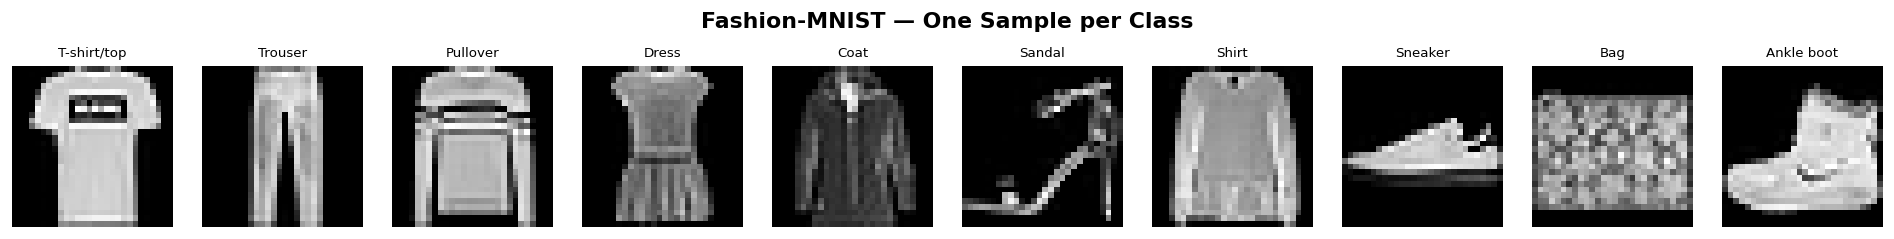

/tmp/ipykernel_8609/3692661893.py:20: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(CLASS_NAMES, rotation=30, ha='right')


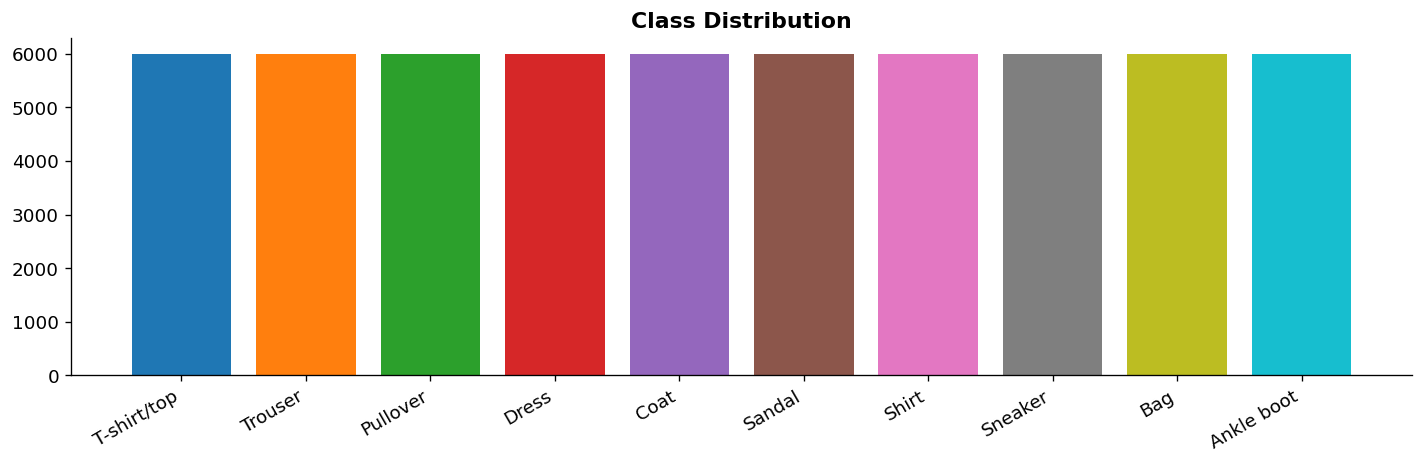

Mean=0.2845  Std=0.3535  Min=0.0000  Max=1.0000


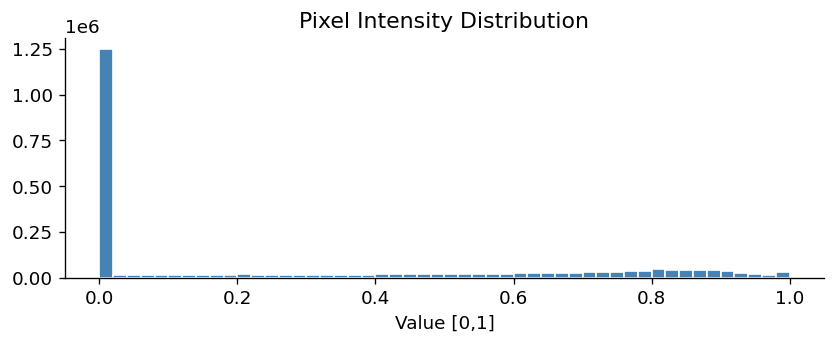

In [ ]:
# ── Sample images ─────────────────────────────────────────────────────────────
shown, samples = {i: False for i in range(10)}, [None]*10
for img, lbl in full_train:
    if not shown[lbl]:
        samples[lbl] = img; shown[lbl] = True
    if all(shown.values()): break

fig, axes = plt.subplots(1, 10, figsize=(16, 2))
for i, (img, name) in enumerate(zip(samples, CLASS_NAMES)):
    axes[i].imshow(img.squeeze(), cmap='gray')
    axes[i].set_title(name, fontsize=8); axes[i].axis('off')
fig.suptitle('Fashion-MNIST — One Sample per Class', fontweight='bold')
plt.tight_layout(); plt.savefig('eda_samples.png', bbox_inches='tight'); plt.show()

# ── Class distribution ────────────────────────────────────────────────────────
counts = np.bincount([full_train[i][1] for i in range(len(full_train))])
fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(CLASS_NAMES, counts, color=sns.color_palette('tab10', 10))
ax.set_title('Class Distribution', fontweight='bold')
ax.set_xticklabels(CLASS_NAMES, rotation=30, ha='right')
plt.tight_layout(); plt.savefig('eda_dist.png', bbox_inches='tight'); plt.show()

# ── Pixel statistics ──────────────────────────────────────────────────────────
px = torch.stack([full_train[i][0] for i in range(3000)]).view(-1)
print(f'Mean={px.mean():.4f}  Std={px.std():.4f}  Min={px.min():.4f}  Max={px.max():.4f}')

fig, ax = plt.subplots(figsize=(7, 3))
ax.hist(px.numpy(), bins=50, color='steelblue', edgecolor='white')
ax.set_title('Pixel Intensity Distribution'); ax.set_xlabel('Value [0,1]')
plt.tight_layout(); plt.savefig('eda_hist.png', bbox_inches='tight'); plt.show()


---
## 2. Model Definitions

In [ ]:
# ── Shared Decoder (used by both AE and VAE) ──────────────────────────────────
class Decoder(nn.Module):
    def __init__(self, latent_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(latent_dim, 256), nn.ReLU(), nn.BatchNorm1d(256),
            nn.Linear(256, 512),        nn.ReLU(), nn.BatchNorm1d(512),
            nn.Linear(512, 784),        nn.Sigmoid(),
        )
    def forward(self, z):
        return self.net(z).view(-1, 1, 28, 28)


# ── Autoencoder ───────────────────────────────────────────────────────────────
class Autoencoder(nn.Module):
    def __init__(self, latent_dim=16):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(784, 512), nn.ReLU(), nn.BatchNorm1d(512),
            nn.Linear(512, 256), nn.ReLU(), nn.BatchNorm1d(256),
            nn.Linear(256, latent_dim),
        )
        self.decoder = Decoder(latent_dim)

    def forward(self, x):
        z     = self.encoder(x.view(x.size(0), -1))
        x_hat = self.decoder(z)
        return x_hat, z


# ── Variational Autoencoder ───────────────────────────────────────────────────
class VAEEncoder(nn.Module):
    def __init__(self, latent_dim):
        super().__init__()
        self.shared = nn.Sequential(
            nn.Linear(784, 512), nn.ReLU(), nn.BatchNorm1d(512),
            nn.Linear(512, 256), nn.ReLU(), nn.BatchNorm1d(256),
        )
        self.fc_mu      = nn.Linear(256, latent_dim)
        self.fc_log_var = nn.Linear(256, latent_dim)

    def forward(self, x):
        h = self.shared(x.view(x.size(0), -1))
        return self.fc_mu(h), self.fc_log_var(h)


class VAE(nn.Module):
    def __init__(self, latent_dim=16):
        super().__init__()
        self.encoder    = VAEEncoder(latent_dim)
        self.decoder    = Decoder(latent_dim)
        self.latent_dim = latent_dim

    def reparameterize(self, mu, log_var):
        # z = mu + sigma * epsilon,  epsilon ~ N(0,I)
        # Only add noise during training; use mean at inference
        if self.training:
            std = torch.exp(0.5 * log_var)
            eps = torch.randn_like(std)
            return mu + std * eps
        return mu

    def forward(self, x):
        mu, log_var = self.encoder(x)
        z           = self.reparameterize(mu, log_var)
        return self.decoder(z), mu, log_var

    @torch.no_grad()
    def generate(self, n, device):
        z = torch.randn(n, self.latent_dim).to(device)
        return self.decoder(z)


# ── VAE Loss ──────────────────────────────────────────────────────────────────
def vae_loss(x_hat, x, mu, log_var, loss_type='bce', beta=1.0):
    B = x.size(0)
    if loss_type == 'bce':
        recon = F.binary_cross_entropy(x_hat, x, reduction='sum') / B
    else:
        recon = F.mse_loss(x_hat, x, reduction='sum') / B
    # KL = -0.5 * sum(1 + log_var - mu^2 - exp(log_var))
    kl    = -0.5 * torch.sum(1 + log_var - mu.pow(2) - log_var.exp()) / B
    return recon + beta * kl, recon, kl


print('Models defined.')


Models defined.


---
## 3. Training Functions (with real W&B logging)

In [ ]:
# ═══════════════════════════════════════════════════════════════════
#  Helper: log a grid of reconstruction images to W&B
# ═══════════════════════════════════════════════════════════════════

@torch.no_grad()
def log_reconstructions_to_wandb(model, loader, device, is_vae, step, tag='recon'):
    model.eval()
    imgs, _ = next(iter(loader))
    imgs    = imgs[:8].to(device)
    if is_vae:
        x_hat, _, _ = model(imgs)
    else:
        x_hat, _    = model(imgs)

    # build side-by-side grid
    fig, axes = plt.subplots(2, 8, figsize=(14, 3))
    for j in range(8):
        axes[0, j].imshow(imgs[j].cpu().squeeze(), cmap='gray'); axes[0, j].axis('off')
        axes[1, j].imshow(x_hat[j].cpu().squeeze(), cmap='gray'); axes[1, j].axis('off')
    axes[0, 0].set_ylabel('Original'); axes[1, 0].set_ylabel('Recon')
    plt.tight_layout()

    wandb.log({tag: wandb.Image(fig)}, step=step)
    plt.close(fig)


# ═══════════════════════════════════════════════════════════════════
#  Autoencoder trainer
# ═══════════════════════════════════════════════════════════════════

def train_autoencoder(config):
    """
    config keys: latent_dim, loss_type, optimizer, lr, epochs
    Initialises a W&B run, trains, logs everything, returns (model, train_losses, val_losses).
    """
    run = wandb.init(
        project = 'fashion-mnist-ae-vae',
        name    = f'AE_{config["loss_type"].upper()}_{config["optimizer"]}_latent{config["latent_dim"]}',
        config  = config,
        reinit  = True,
    )

    model = Autoencoder(latent_dim=config['latent_dim']).to(DEVICE)
    wandb.watch(model, log='gradients', log_freq=50)

    opt_cls = {'sgd': optim.SGD, 'rmsprop': optim.RMSprop, 'adam': optim.Adam}
    lr_override = 0.01 if config['optimizer'] == 'sgd' else config['lr']
    kw  = {'momentum': 0.9} if config['optimizer'] == 'sgd' else {}
    opt = opt_cls[config['optimizer']](model.parameters(), lr=lr_override, **kw)

    loss_fn = nn.BCELoss() if config['loss_type'] == 'bce' else nn.MSELoss()

    train_losses, val_losses = [], []

    for epoch in range(1, config['epochs'] + 1):
        # ── train ──
        model.train(); tr_loss = 0.0
        for imgs, _ in train_loader:
            imgs = imgs.to(DEVICE)
            opt.zero_grad()
            x_hat, _ = model(imgs)
            loss = loss_fn(x_hat, imgs)
            loss.backward(); opt.step()
            tr_loss += loss.item() * imgs.size(0)
        tr_loss /= len(train_loader.dataset)

        # ── validate ──
        model.eval(); vl_loss = 0.0
        with torch.no_grad():
            for imgs, _ in val_loader:
                imgs = imgs.to(DEVICE)
                x_hat, _ = model(imgs)
                vl_loss += loss_fn(x_hat, imgs).item() * imgs.size(0)
        vl_loss /= len(val_loader.dataset)

        train_losses.append(tr_loss); val_losses.append(vl_loss)

        # ── log to W&B ──
        wandb.log({'train/loss': tr_loss, 'val/loss': vl_loss, 'epoch': epoch}, step=epoch)

        # log reconstruction images every 5 epochs
        if epoch % 5 == 0 or epoch == 1:
            log_reconstructions_to_wandb(model, test_loader, DEVICE,
                                          is_vae=False, step=epoch,
                                          tag='reconstructions')
            print(f'  [{epoch:3d}/{config["epochs"]}]  Train={tr_loss:.4f}  Val={vl_loss:.4f}')

    # save model artifact
    ckpt = f'ae_{config["loss_type"]}_{config["optimizer"]}_latent{config["latent_dim"]}.pth'
    torch.save(model.state_dict(), ckpt)
    artifact = wandb.Artifact('autoencoder', type='model')
    artifact.add_file(ckpt)
    run.log_artifact(artifact)

    run.finish()
    return model, train_losses, val_losses


# ═══════════════════════════════════════════════════════════════════
#  VAE trainer
# ═══════════════════════════════════════════════════════════════════

def train_vae(config):
    """
    config keys: latent_dim, loss_type, optimizer, lr, epochs, beta
    """
    run = wandb.init(
        project = 'fashion-mnist-ae-vae',
        name    = f'VAE_{config["loss_type"].upper()}_{config["optimizer"]}_latent{config["latent_dim"]}',
        config  = config,
        reinit  = True,
    )

    model = VAE(latent_dim=config['latent_dim']).to(DEVICE)
    wandb.watch(model, log='gradients', log_freq=50)

    opt_cls = {'sgd': optim.SGD, 'rmsprop': optim.RMSprop, 'adam': optim.Adam}
    lr_override = 0.01 if config['optimizer'] == 'sgd' else config['lr']
    kw  = {'momentum': 0.9} if config['optimizer'] == 'sgd' else {}
    opt = opt_cls[config['optimizer']](model.parameters(), lr=lr_override, **kw)

    history = {'train_total':[], 'train_recon':[], 'train_kl':[],
               'val_total':[],   'val_recon':[],   'val_kl':[]}

    for epoch in range(1, config['epochs'] + 1):
        # ── train ──
        model.train(); tr = {'total':0.,'recon':0.,'kl':0.}
        for imgs, _ in train_loader:
            imgs = imgs.to(DEVICE)
            opt.zero_grad()
            x_hat, mu, lv = model(imgs)
            tot, rec, kl  = vae_loss(x_hat, imgs, mu, lv,
                                      config['loss_type'], config['beta'])
            tot.backward(); opt.step()
            n = imgs.size(0)
            tr['total'] += tot.item()*n; tr['recon'] += rec.item()*n; tr['kl'] += kl.item()*n
        N = len(train_loader.dataset)
        tr = {k: v/N for k, v in tr.items()}

        # ── validate ──
        model.eval(); vl = {'total':0.,'recon':0.,'kl':0.}
        with torch.no_grad():
            for imgs, _ in val_loader:
                imgs = imgs.to(DEVICE)
                x_hat, mu, lv = model(imgs)
                tot, rec, kl  = vae_loss(x_hat, imgs, mu, lv,
                                          config['loss_type'], config['beta'])
                n = imgs.size(0)
                vl['total'] += tot.item()*n; vl['recon'] += rec.item()*n; vl['kl'] += kl.item()*n
        N = len(val_loader.dataset)
        vl = {k: v/N for k, v in vl.items()}

        for k in ['total','recon','kl']:
            history[f'train_{k}'].append(tr[k])
            history[f'val_{k}'].append(vl[k])

        # ── log to W&B ──
        wandb.log({
            'train/total': tr['total'], 'train/recon': tr['recon'], 'train/kl': tr['kl'],
            'val/total':   vl['total'], 'val/recon':   vl['recon'], 'val/kl':   vl['kl'],
            'epoch': epoch
        }, step=epoch)

        if epoch % 5 == 0 or epoch == 1:
            log_reconstructions_to_wandb(model, test_loader, DEVICE,
                                          is_vae=True, step=epoch,
                                          tag='reconstructions')

            # log generated samples
            gen_imgs = model.generate(8, DEVICE)
            fig, axes = plt.subplots(1, 8, figsize=(14, 2))
            for j, ax in enumerate(axes):
                ax.imshow(gen_imgs[j].cpu().squeeze(), cmap='gray'); ax.axis('off')
            plt.tight_layout()
            wandb.log({'generated_samples': wandb.Image(fig)}, step=epoch)
            plt.close(fig)

            print(f'  [{epoch:3d}/{config["epochs"]}]  '
                  f'Total={tr["total"]:.2f}  Recon={tr["recon"]:.2f}  KL={tr["kl"]:.2f}')

    # save model artifact
    ckpt = f'vae_{config["loss_type"]}_{config["optimizer"]}_latent{config["latent_dim"]}.pth'
    torch.save(model.state_dict(), ckpt)
    artifact = wandb.Artifact('vae', type='model')
    artifact.add_file(ckpt)
    run.log_artifact(artifact)

    run.finish()
    return model, history


print('Training functions ready.')


Training functions ready.


---
## 4. Part A — Train Autoencoder (MSE + BCE)

In [ ]:
EPOCHS     = 30
LATENT_DIM = 16

# ── AE with MSE ───────────────────────────────────────────────────
print('>>> AE + MSE')
ae_mse, ae_mse_tr, ae_mse_vl = train_autoencoder({
    'latent_dim': LATENT_DIM, 'loss_type': 'mse',
    'optimizer': 'adam', 'lr': 1e-3, 'epochs': EPOCHS
})

# ── AE with BCE ───────────────────────────────────────────────────
print('\n>>> AE + BCE')
ae_bce, ae_bce_tr, ae_bce_vl = train_autoencoder({
    'latent_dim': LATENT_DIM, 'loss_type': 'bce',
    'optimizer': 'adam', 'lr': 1e-3, 'epochs': EPOCHS
})


wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /home/paras/.netrc.


>>> AE + MSE


wandb: Currently logged in as: paras178a (paras178a-graphic-era-university) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin
wandb: WARNING Using a boolean value for 'reinit' is deprecated. Use 'return_previous' or 'finish_previous' instead.


  [  1/30]  Train=0.0483  Val=0.0225
  [  5/30]  Train=0.0130  Val=0.0122
  [ 10/30]  Train=0.0114  Val=0.0112
  [ 15/30]  Train=0.0108  Val=0.0106
  [ 20/30]  Train=0.0104  Val=0.0104
  [ 25/30]  Train=0.0101  Val=0.0101
  [ 30/30]  Train=0.0099  Val=0.0100


wandb: ERROR The nbformat package was not found. It is required to save notebook history.


epoch,▁▁▁▂▂▂▂▃▃▃▃▄▄▄▄▅▅▅▅▆▆▆▆▇▇▇▇███
train/loss,█▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
val/loss,█▄▃▃▂▂▂▂▂▂▂▂▁▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
epoch,30
train/loss,0.00988
val/loss,0.00996



>>> AE + BCE


  [  1/30]  Train=0.3854  Val=0.2928
  [  5/30]  Train=0.2791  Val=0.2762
  [ 10/30]  Train=0.2755  Val=0.2740
  [ 15/30]  Train=0.2739  Val=0.2717
  [ 20/30]  Train=0.2726  Val=0.2709
  [ 25/30]  Train=0.2718  Val=0.2700
  [ 30/30]  Train=0.2713  Val=0.2700


wandb: ERROR The nbformat package was not found. It is required to save notebook history.


epoch,▁▁▁▂▂▂▂▃▃▃▃▄▄▄▄▅▅▅▅▆▆▆▆▇▇▇▇███
train/loss,█▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
val/loss,█▅▅▃▃▃▃▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
epoch,30
train/loss,0.27126
val/loss,0.27004


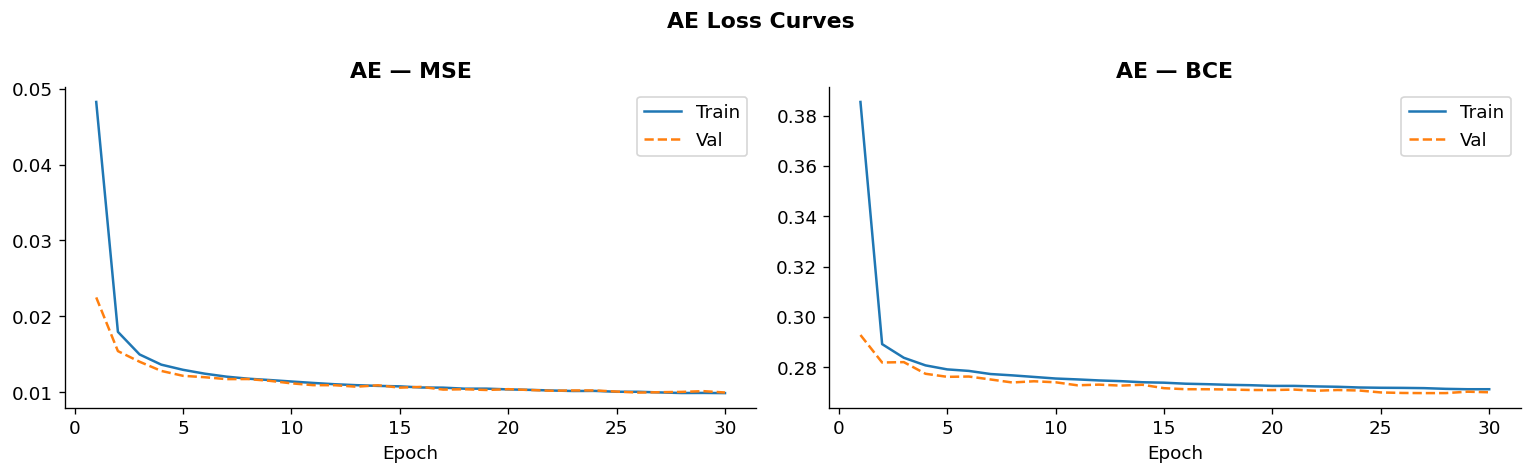

In [7]:
# ── Loss curves (local plot) ──────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, (name, tr, vl) in zip(axes, [
        ('AE — MSE', ae_mse_tr, ae_mse_vl),
        ('AE — BCE', ae_bce_tr, ae_bce_vl)]):
    ep = range(1, len(tr)+1)
    ax.plot(ep, tr, label='Train'); ax.plot(ep, vl, label='Val', linestyle='--')
    ax.set_title(name, fontweight='bold'); ax.set_xlabel('Epoch'); ax.legend()
plt.suptitle('AE Loss Curves', fontweight='bold')
plt.tight_layout(); plt.savefig('ae_loss.png', bbox_inches='tight'); plt.show()


---
## 5. Part B — Train VAE

In [8]:
print('>>> VAE + BCE, latent=16')
vae_main, vae_hist = train_vae({
    'latent_dim': LATENT_DIM, 'loss_type': 'bce',
    'optimizer': 'adam', 'lr': 1e-3, 'epochs': EPOCHS, 'beta': 1.0
})


>>> VAE + BCE, latent=16


  [  1/30]  Total=331.21  Recon=318.79  KL=12.43
  [  5/30]  Total=246.27  Recon=231.17  KL=15.10
  [ 10/30]  Total=242.54  Recon=227.15  KL=15.39
  [ 15/30]  Total=240.93  Recon=225.47  KL=15.45
  [ 20/30]  Total=239.95  Recon=224.42  KL=15.52
  [ 25/30]  Total=239.23  Recon=223.62  KL=15.62
  [ 30/30]  Total=238.72  Recon=223.04  KL=15.68


epoch,▁▁▁▂▂▂▂▃▃▃▃▄▄▄▄▅▅▅▅▆▆▆▆▇▇▇▇███
train/kl,▁▅▆▆▇▇▇▇▇▇▇▇██████████████████
train/recon,█▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
train/total,█▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
val/kl,▁▃▄▄▅▅▆▇▆▆▇▆▇▆▇▇▇▆▇▆▇▇▇▆▇▇▆▇▇█
val/recon,█▆▄▃▃▃▃▂▂▂▂▂▂▂▂▁▂▁▂▁▁▁▁▁▁▁▁▁▁▁
val/total,█▆▄▃▃▃▃▂▂▂▂▂▂▂▂▁▂▁▂▁▁▁▁▁▁▁▁▁▁▁
epoch,30
train/kl,15.68
train/recon,223.04241
train/total,238.72242


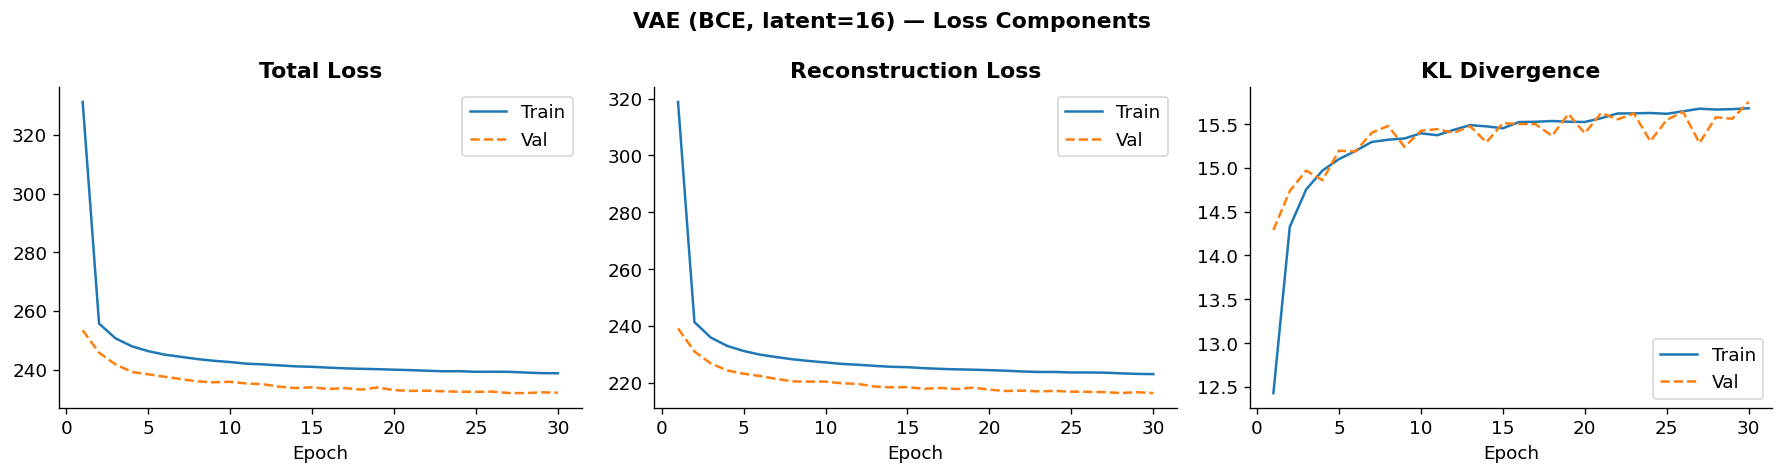

In [9]:
# ── VAE 3-component loss curves ───────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
ep = range(1, EPOCHS+1)
for ax, key, label in zip(axes,
        ['total','recon','kl'],
        ['Total Loss','Reconstruction Loss','KL Divergence']):
    ax.plot(ep, vae_hist[f'train_{key}'], label='Train')
    ax.plot(ep, vae_hist[f'val_{key}'],   label='Val', linestyle='--')
    ax.set_title(label, fontweight='bold'); ax.set_xlabel('Epoch'); ax.legend()
plt.suptitle('VAE (BCE, latent=16) — Loss Components', fontweight='bold')
plt.tight_layout(); plt.savefig('vae_loss.png', bbox_inches='tight'); plt.show()


---
## 6. Latent Dimension Experiments (2, 8, 16, 32)

In [10]:
LATENT_DIMS = [2, 8, 16, 32]
vae_models  = {}

for ld in LATENT_DIMS:
    print(f'\n>>> VAE latent_dim={ld}')
    model, _ = train_vae({
        'latent_dim': ld, 'loss_type': 'bce',
        'optimizer': 'adam', 'lr': 1e-3, 'epochs': 20, 'beta': 1.0
    })
    vae_models[ld] = model



>>> VAE latent_dim=2


  [  1/20]  Total=347.84  Recon=340.71  KL=7.13
  [  5/20]  Total=264.09  Recon=257.99  KL=6.10
  [ 10/20]  Total=261.26  Recon=255.03  KL=6.23
  [ 15/20]  Total=260.00  Recon=253.70  KL=6.30
  [ 20/20]  Total=259.06  Recon=252.69  KL=6.37


epoch,▁▁▂▂▂▃▃▄▄▄▅▅▅▆▆▇▇▇██
train/kl,█▁▂▂▃▃▃▃▃▃▃▃▃▄▄▄▄▄▄▄
train/recon,█▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
train/total,█▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
val/kl,▁▂▃▃▃▅▅▄▆▅▇▅▆▆▆▆██▇▇
val/recon,█▅▄▄▃▃▃▂▃▂▂▂▂▁▁▁▂▁▁▁
val/total,█▅▄▄▃▃▃▂▃▂▂▂▂▁▁▁▂▁▁▁
epoch,20
train/kl,6.37411
train/recon,252.68637
train/total,259.06048



>>> VAE latent_dim=8


  [  1/20]  Total=330.26  Recon=319.63  KL=10.63
  [  5/20]  Total=245.35  Recon=232.15  KL=13.20
  [ 10/20]  Total=241.95  Recon=228.42  KL=13.53
  [ 15/20]  Total=240.87  Recon=227.24  KL=13.64
  [ 20/20]  Total=239.80  Recon=226.08  KL=13.72


...

  [  1/20]  Total=331.32  Recon=318.99  KL=12.33
  [  5/20]  Total=246.26  Recon=231.25  KL=15.00
  [ 10/20]  Total=242.22  Recon=227.11  KL=15.11
  [ 15/20]  Total=240.61  Recon=225.37  KL=15.25
  [ 20/20]  Total=239.68  Recon=224.36  KL=15.31


epoch,▁▁▂▂▂▃▃▄▄▄▅▅▅▆▆▇▇▇██
train/kl,▁▆▇▇▇▇▇▇████████████
train/recon,█▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
train/total,█▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
val/kl,▁▆▆▆▆▆▆▆▇▇▆▇▇▆█▇█▇▇▇
val/recon,█▅▄▃▃▃▂▂▂▂▂▂▁▁▂▁▁▁▁▁
val/total,█▅▄▃▃▃▂▂▂▂▂▂▁▁▂▁▁▁▁▁
epoch,20
train/kl,15.31194
train/recon,224.36354
train/total,239.67548



>>> VAE latent_dim=32


  [  1/20]  Total=333.64  Recon=319.94  KL=13.70
  [  5/20]  Total=246.89  Recon=232.17  KL=14.72
  [ 10/20]  Total=242.42  Recon=227.44  KL=14.98
  [ 15/20]  Total=240.73  Recon=225.59  KL=15.14
  [ 20/20]  Total=239.85  Recon=224.63  KL=15.22


epoch,▁▁▂▂▂▃▃▄▄▄▅▅▅▆▆▇▇▇██
train/kl,▁▇▆▅▆▆▆▆▇▇▇▇▇█▇█████
train/recon,█▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
train/total,█▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
val/kl,▇█▁▃▃▅▄▅▅▅▆▅▆▆▅▇▆▆▆▇
val/recon,█▆▄▄▃▃▂▂▂▂▂▂▁▁▁▁▁▁▁▁
val/total,█▆▄▄▃▃▂▂▂▂▂▂▁▁▁▁▁▁▁▁
epoch,20
train/kl,15.21668
train/recon,224.63449
train/total,239.85116


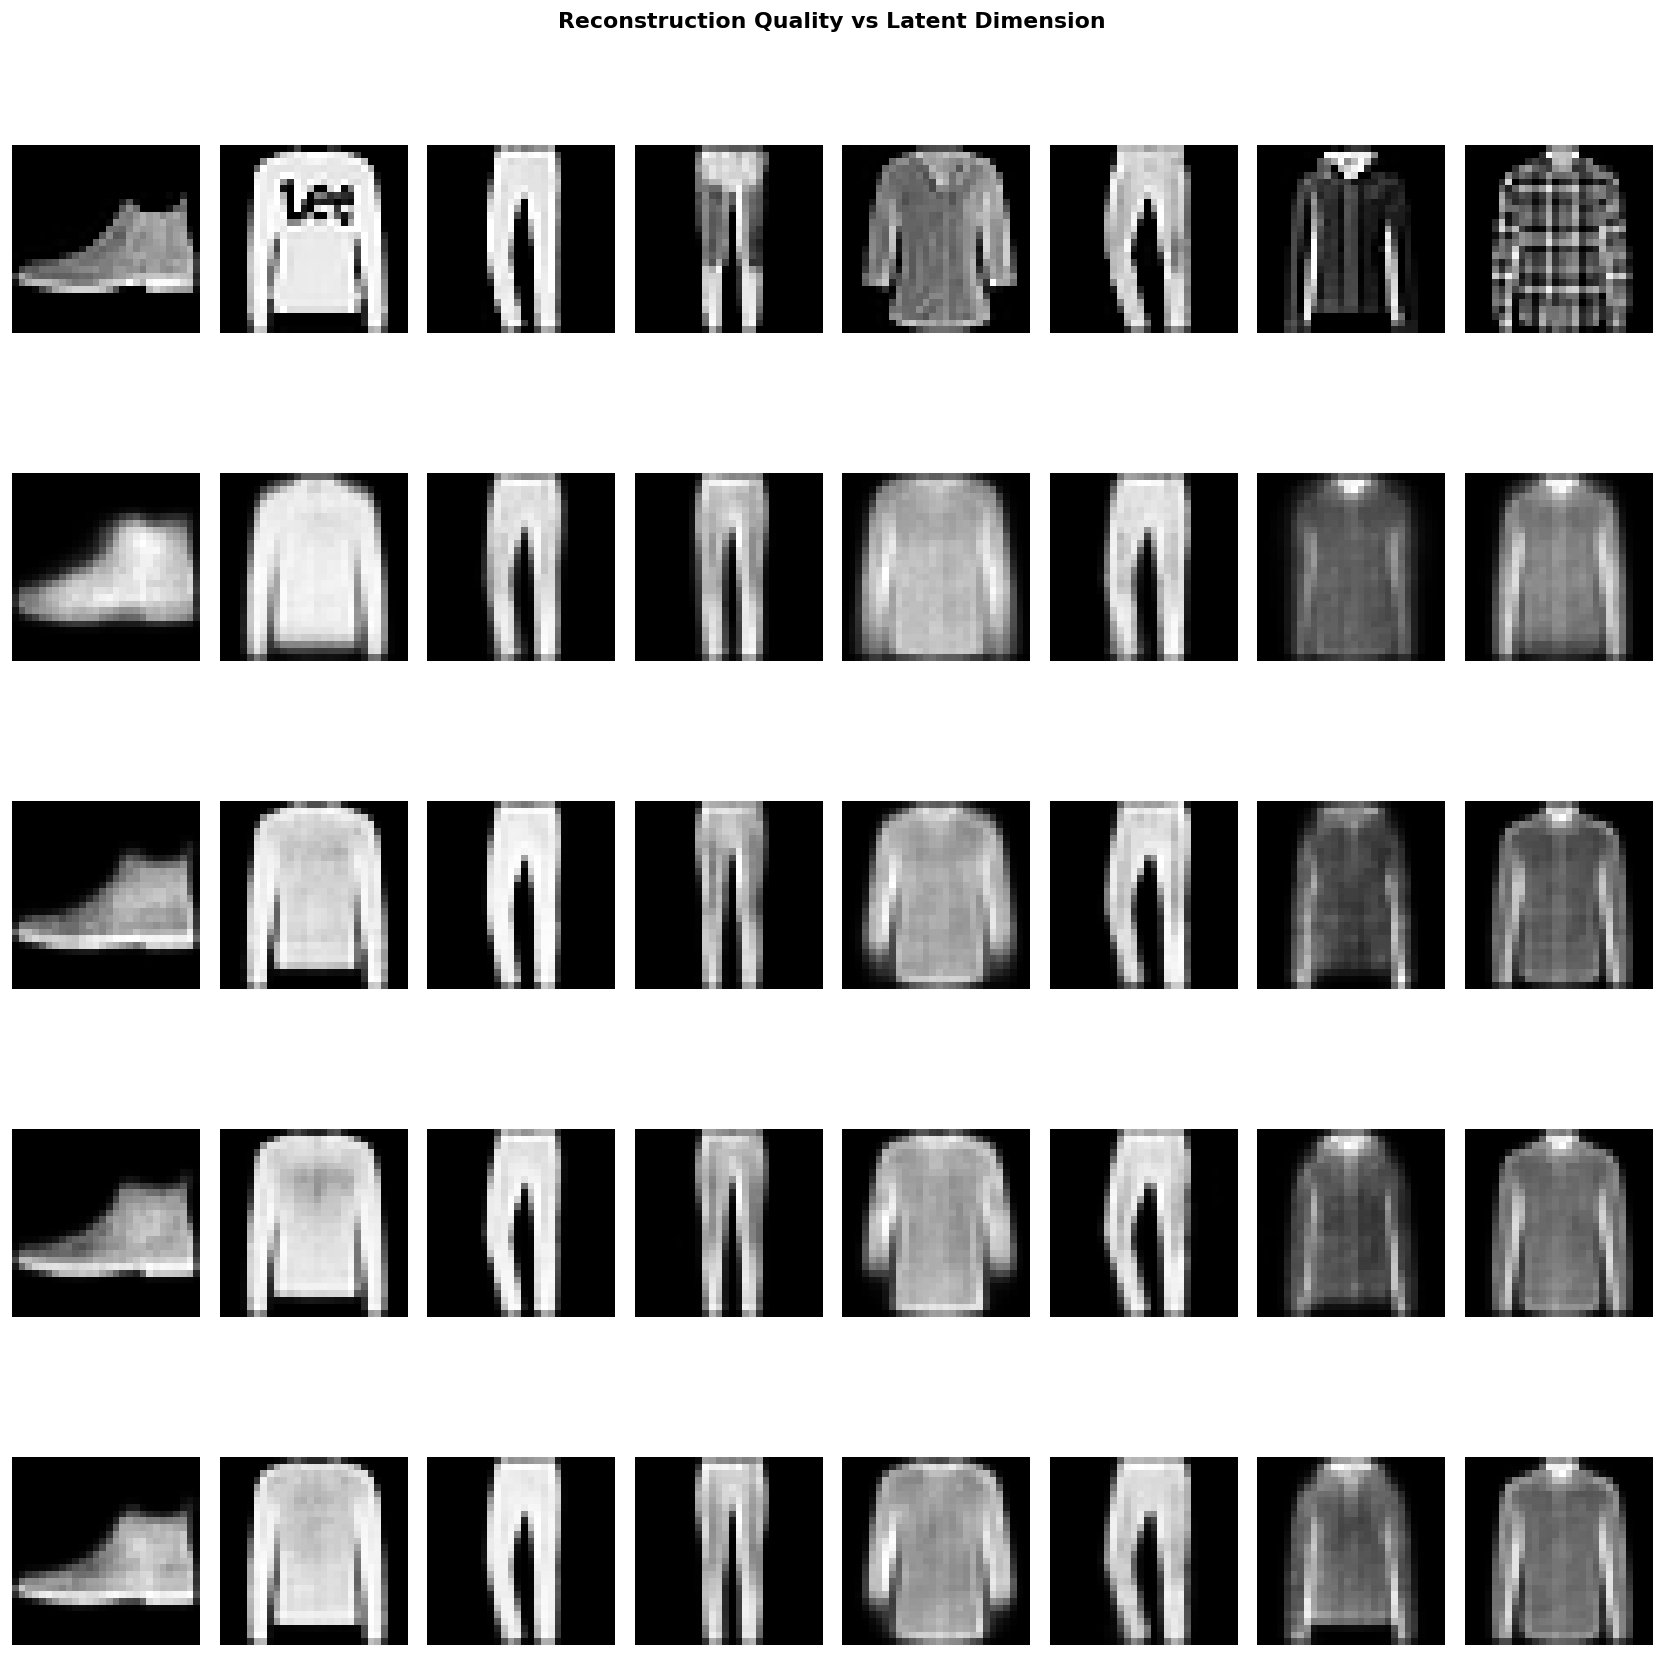

In [11]:
# ── Reconstruction quality grid ───────────────────────────────────
fixed_imgs = next(iter(test_loader))[0][:8].to(DEVICE)

fig, axes = plt.subplots(len(LATENT_DIMS)+1, 8, figsize=(14, 3*(len(LATENT_DIMS)+1)))
for j in range(8):
    axes[0,j].imshow(fixed_imgs[j].cpu().squeeze(), cmap='gray'); axes[0,j].axis('off')
axes[0,0].set_ylabel('Original', fontsize=9)

for i, ld in enumerate(LATENT_DIMS, 1):
    with torch.no_grad():
        vae_models[ld].eval()
        xh, _, _ = vae_models[ld](fixed_imgs)
    for j in range(8):
        axes[i,j].imshow(xh[j].cpu().squeeze(), cmap='gray'); axes[i,j].axis('off')
    axes[i,0].set_ylabel(f'z={ld}', fontsize=9)

plt.suptitle('Reconstruction Quality vs Latent Dimension', fontweight='bold')
plt.tight_layout(); plt.savefig('latent_dim_recon.png', bbox_inches='tight'); plt.show()


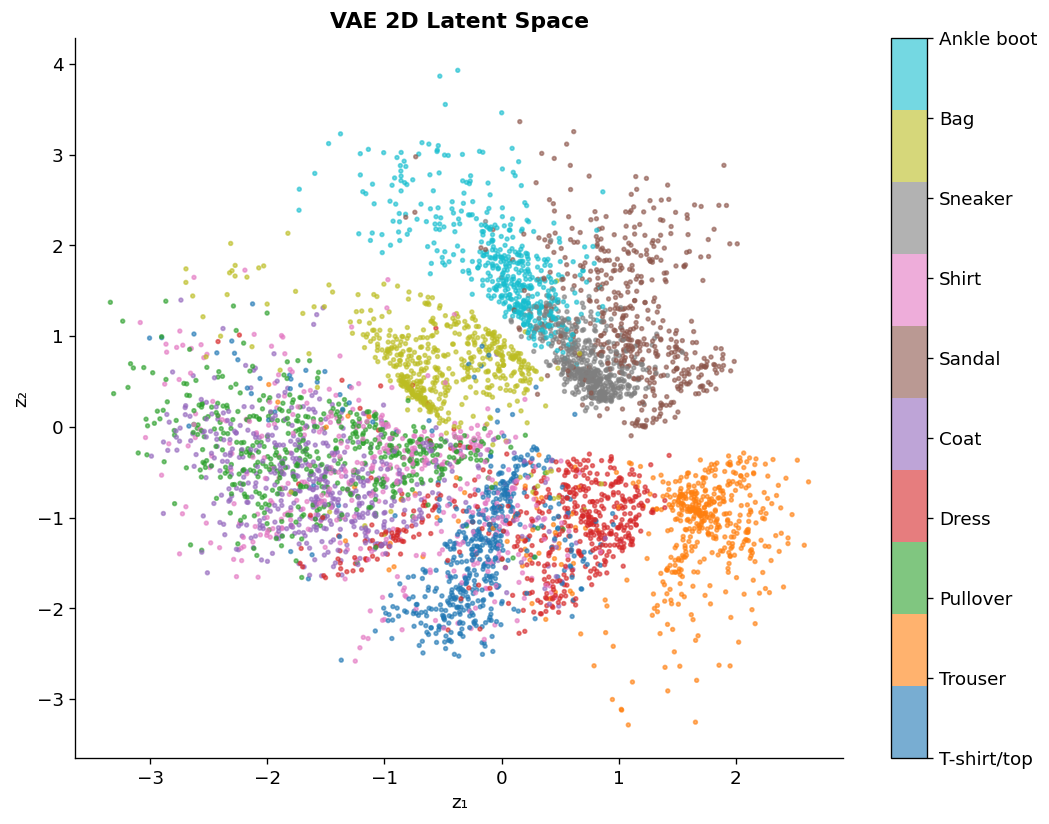

In [12]:
# ── 2D latent space scatter ───────────────────────────────────────
@torch.no_grad()
def get_latents(model, loader, device, max_n=5000):
    model.eval(); zs, ls = [], []
    for imgs, lbls in loader:
        mu, _ = model.encoder(imgs.to(device))
        zs.append(mu.cpu().numpy()); ls.append(lbls.numpy())
        if sum(len(z) for z in zs) >= max_n: break
    return np.concatenate(zs)[:max_n], np.concatenate(ls)[:max_n]


z2, l2 = get_latents(vae_models[2], test_loader, DEVICE)

fig, ax = plt.subplots(figsize=(9, 7))
sc = ax.scatter(z2[:,0], z2[:,1], c=l2, cmap='tab10', s=5, alpha=0.6)
plt.colorbar(sc, ax=ax, ticks=range(10)).ax.set_yticklabels(CLASS_NAMES)
ax.set_title('VAE 2D Latent Space', fontweight='bold')
ax.set_xlabel('z₁'); ax.set_ylabel('z₂')
plt.tight_layout(); plt.savefig('latent_2d.png', bbox_inches='tight'); plt.show()

# Log to W&B as a scatter table
run = wandb.init(project='fashion-mnist-ae-vae', name='latent_space_analysis', reinit=True)
table = wandb.Table(columns=['z1','z2','class'])
for z, lbl in zip(z2, l2):
    table.add_data(float(z[0]), float(z[1]), CLASS_NAMES[lbl])
wandb.log({'latent_2d_scatter': wandb.plot.scatter(table, 'z1', 'z2',
            title='VAE 2D Latent Space')})
wandb.log({'latent_2d_image': wandb.Image('latent_2d.png')})
run.finish()


Running t-SNE…


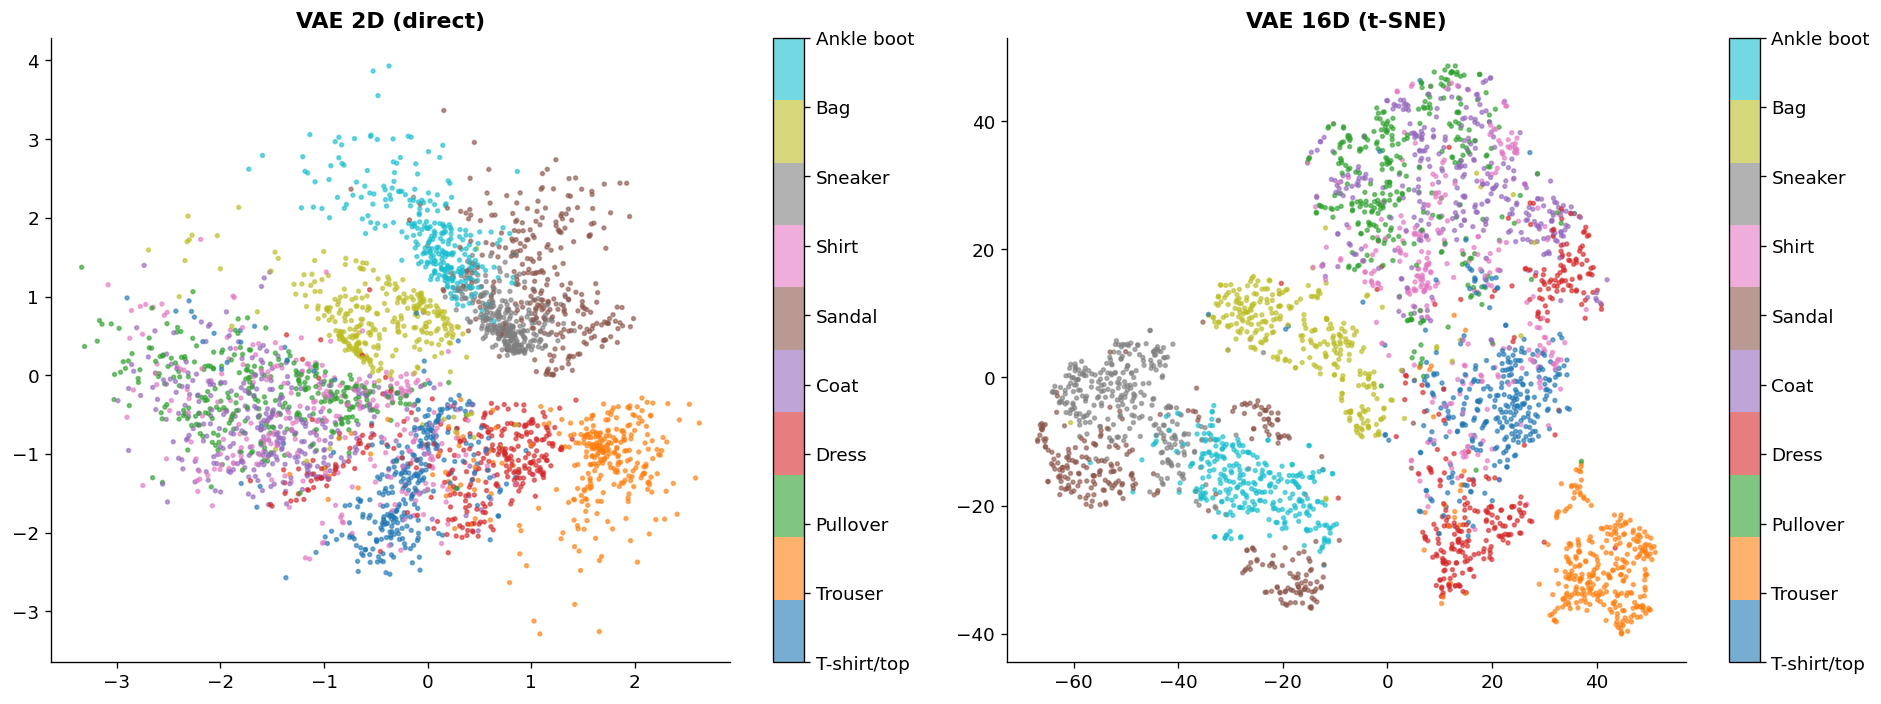

In [13]:
# ── t-SNE on 16D latent ───────────────────────────────────────────
z16, l16 = get_latents(vae_models[16], test_loader, DEVICE, max_n=3000)
print('Running t-SNE…')
z16_tsne = TSNE(n_components=2, random_state=SEED, perplexity=40).fit_transform(z16)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for ax, z, l, title in zip(axes,
        [z2[:3000], z16_tsne], [l2[:3000], l16],
        ['VAE 2D (direct)', 'VAE 16D (t-SNE)']):
    sc = ax.scatter(z[:,0], z[:,1], c=l, cmap='tab10', s=5, alpha=0.6)
    plt.colorbar(sc, ax=ax, ticks=range(10)).ax.set_yticklabels(CLASS_NAMES)
    ax.set_title(title, fontweight='bold')
plt.tight_layout(); plt.savefig('tsne_comparison.png', bbox_inches='tight'); plt.show()


---
## 7. Latent Space Interpolation

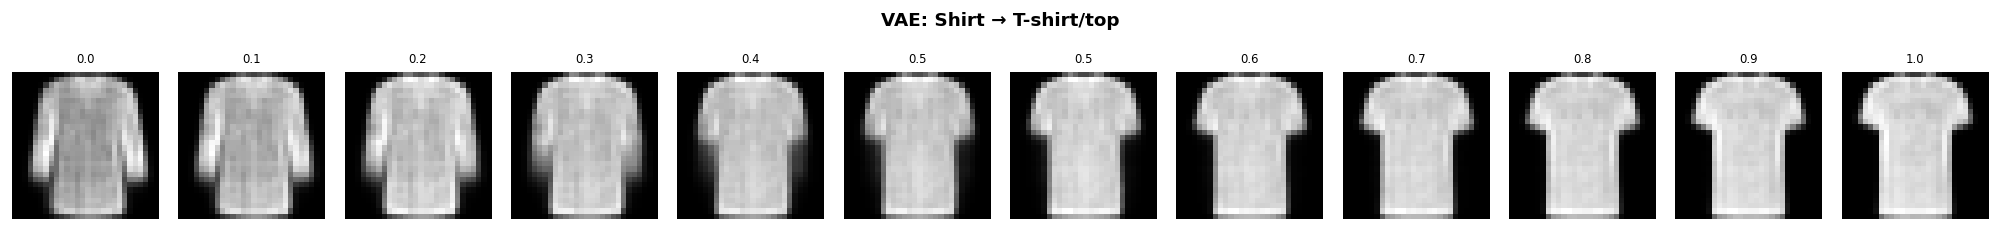

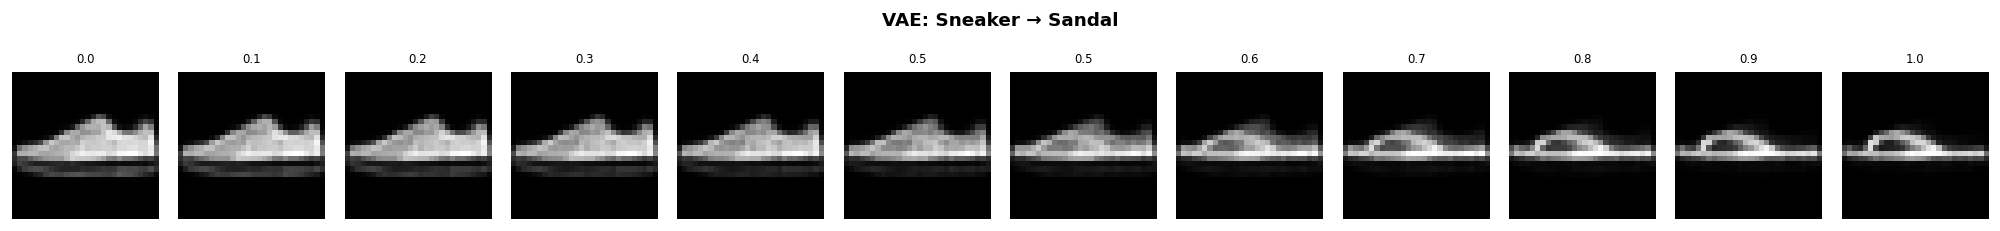

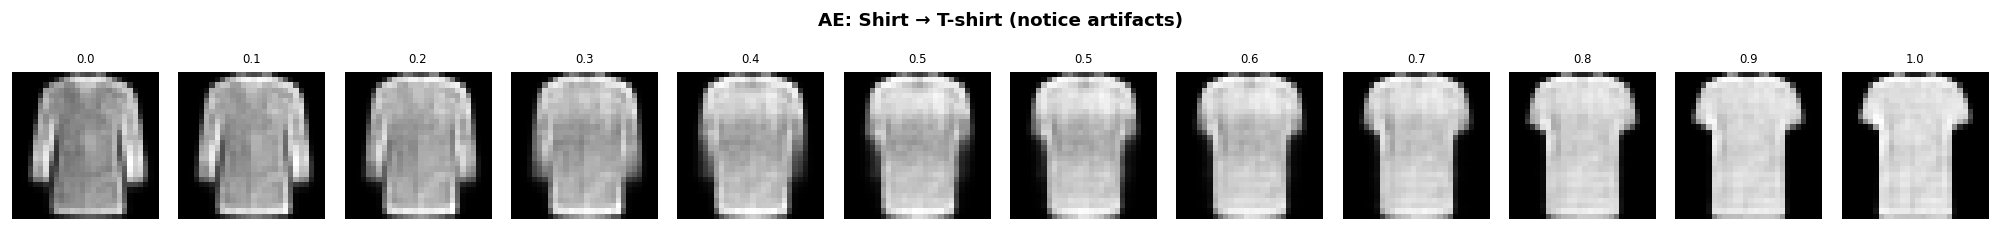

In [14]:
def get_class_img(dataset, cls_id):
    for img, lbl in dataset:
        if lbl == cls_id: return img


@torch.no_grad()
def interpolate(model, img1, img2, device, n_steps=12, is_vae=True,
                title='', save_path=None, wandb_tag=None):
    model.eval()
    i1 = img1.unsqueeze(0).to(device)
    i2 = img2.unsqueeze(0).to(device)

    z1 = model.encoder(i1)[0] if is_vae else model.encoder(i1.view(1,-1))
    z2 = model.encoder(i2)[0] if is_vae else model.encoder(i2.view(1,-1))

    alphas = torch.linspace(0, 1, n_steps)
    imgs   = [model.decoder((1-a)*z1 + a*z2).cpu().squeeze() for a in alphas]

    fig, axes = plt.subplots(1, n_steps, figsize=(n_steps*1.4, 2))
    for ax, img, a in zip(axes, imgs, alphas):
        ax.imshow(img.numpy(), cmap='gray')
        ax.set_title(f'{a:.1f}', fontsize=7); ax.axis('off')
    fig.suptitle(title, fontsize=11, fontweight='bold')
    plt.tight_layout()
    if save_path: plt.savefig(save_path, bbox_inches='tight')
    if wandb_tag:
        wandb.log({wandb_tag: wandb.Image(fig)})
    plt.show(); plt.close(fig)


# Start a dedicated interpolation run
run = wandb.init(project='fashion-mnist-ae-vae', name='latent_interpolation', reinit=True)

interpolate(vae_main,
            get_class_img(test_ds, 6),   # Shirt
            get_class_img(test_ds, 0),   # T-shirt
            DEVICE, title='VAE: Shirt → T-shirt/top',
            save_path='interp_shirt_tshirt.png',
            wandb_tag='interp/shirt_to_tshirt')

interpolate(vae_main,
            get_class_img(test_ds, 7),   # Sneaker
            get_class_img(test_ds, 5),   # Sandal
            DEVICE, title='VAE: Sneaker → Sandal',
            save_path='interp_sneaker_sandal.png',
            wandb_tag='interp/sneaker_to_sandal')

interpolate(ae_bce,
            get_class_img(test_ds, 6),
            get_class_img(test_ds, 0),
            DEVICE, is_vae=False, title='AE: Shirt → T-shirt (notice artifacts)',
            save_path='interp_ae_shirt_tshirt.png',
            wandb_tag='interp/AE_shirt_to_tshirt')

run.finish()


---
## 8. Optimizer Comparison

In [15]:
OPT_EPOCHS = 20
ae_opt_res, vae_opt_res = {}, {}

for opt_name in ['sgd', 'rmsprop', 'adam']:
    print(f'\n>>> AE + {opt_name.upper()}')
    model, tr, vl = train_autoencoder({
        'latent_dim': LATENT_DIM, 'loss_type': 'bce',
        'optimizer': opt_name, 'lr': 1e-3, 'epochs': OPT_EPOCHS
    })
    ae_opt_res[opt_name] = {'model': model, 'train': tr, 'val': vl}

    print(f'\n>>> VAE + {opt_name.upper()}')
    model, hist = train_vae({
        'latent_dim': LATENT_DIM, 'loss_type': 'bce',
        'optimizer': opt_name, 'lr': 1e-3, 'epochs': OPT_EPOCHS, 'beta': 1.0
    })
    vae_opt_res[opt_name] = {'model': model, 'hist': hist}



>>> AE + SGD


  [  1/20]  Train=0.6790  Val=0.6321
  [  5/20]  Train=0.5651  Val=0.5590
  [ 10/20]  Train=0.5148  Val=0.5072
  [ 15/20]  Train=0.4326  Val=0.4217
  [ 20/20]  Train=0.3618  Val=0.3546


epoch,▁▁▂▂▂▃▃▄▄▄▅▅▅▆▆▇▇▇██
train/loss,█▇▆▆▅▅▅▅▅▄▄▄▃▃▃▂▂▁▁▁
val/loss,█▇▇▆▆▆▆▅▅▅▄▄▄▃▃▂▂▂▁▁
epoch,20
train/loss,0.36175
val/loss,0.35463



>>> VAE + SGD


  [  1/20]  Total=300.01  Recon=283.08  KL=16.93
  [  5/20]  Total=248.76  Recon=237.40  KL=11.37
  [ 10/20]  Total=245.79  Recon=234.01  KL=11.78
  [ 15/20]  Total=243.80  Recon=231.92  KL=11.88
  [ 20/20]  Total=243.29  Recon=231.34  KL=11.95


...

  [  1/20]  Train=0.3869  Val=0.2930
  [  5/20]  Train=0.2795  Val=0.2761
  [ 10/20]  Train=0.2755  Val=0.2730
  [ 15/20]  Train=0.2737  Val=0.2715
  [ 20/20]  Train=0.2726  Val=0.2716


epoch,▁▁▂▂▂▃▃▄▄▄▅▅▅▆▆▇▇▇██
train/loss,█▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
val/loss,█▅▄▃▃▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁
epoch,20
train/loss,0.27264
val/loss,0.27158



>>> VAE + ADAM


  [  1/20]  Total=330.75  Recon=318.36  KL=12.39
  [  5/20]  Total=246.82  Recon=231.45  KL=15.37
  [ 10/20]  Total=242.68  Recon=227.10  KL=15.58
  [ 15/20]  Total=241.13  Recon=225.38  KL=15.75
  [ 20/20]  Total=240.01  Recon=224.19  KL=15.82


epoch,▁▁▂▂▂▃▃▄▄▄▅▅▅▆▆▇▇▇██
train/kl,▁▅▇▇▇▇▇▇▇███████████
train/recon,█▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
train/total,█▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
val/kl,▁▅▆▆▆█▇▆▇▇▇█▇▇▇█▇███
val/recon,█▅▄▃▃▃▂▂▂▂▂▁▂▁▁▁▁▁▁▁
val/total,█▅▅▃▃▃▂▂▂▂▂▁▂▁▁▁▁▁▁▁
epoch,20
train/kl,15.823
train/recon,224.1914
train/total,240.0144


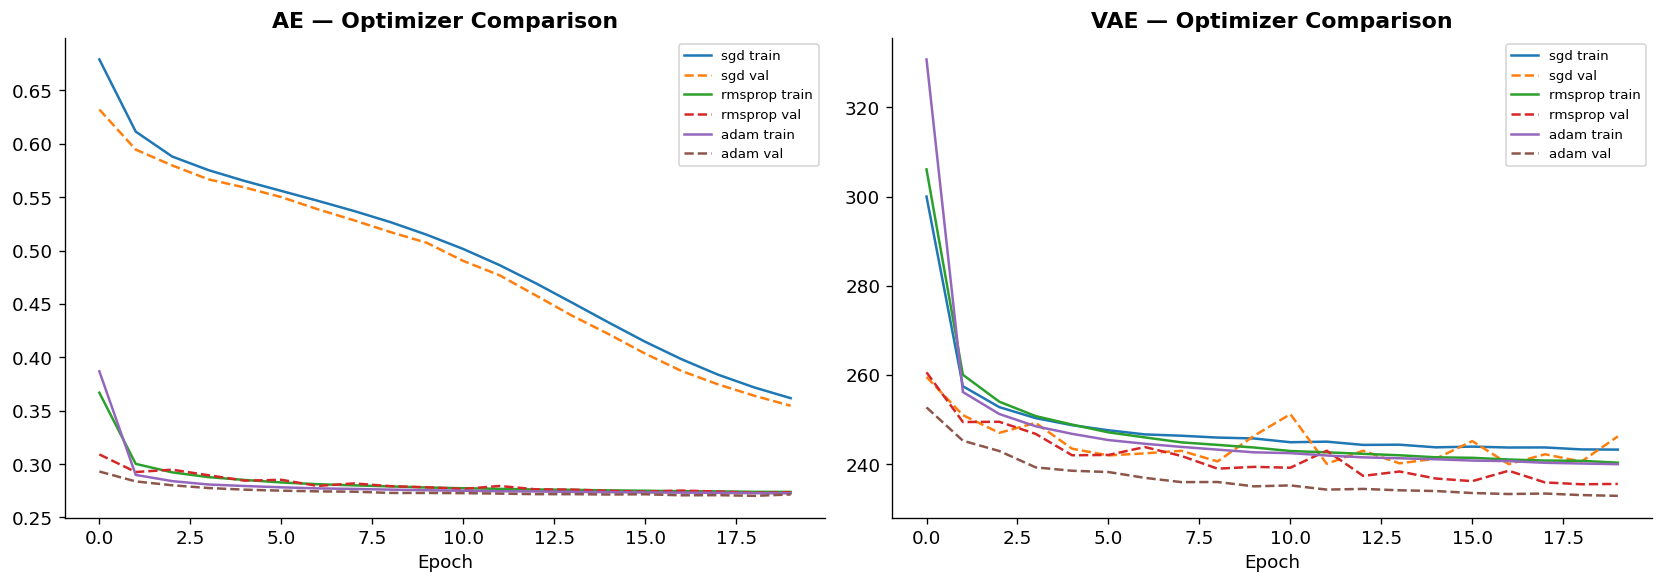


Optimizer    AE Val Loss   VAE Val Total
----------------------------------------
sgd               0.3546        246.2559
rmsprop           0.2736        235.5958
adam              0.2716        232.9228


In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for name, res in ae_opt_res.items():
    axes[0].plot(res['train'], label=f'{name} train')
    axes[0].plot(res['val'],   label=f'{name} val', linestyle='--')
axes[0].set_title('AE — Optimizer Comparison', fontweight='bold')
axes[0].set_xlabel('Epoch'); axes[0].legend(fontsize=8)

for name, res in vae_opt_res.items():
    h = res['hist']
    axes[1].plot(h['train_total'], label=f'{name} train')
    axes[1].plot(h['val_total'],   label=f'{name} val', linestyle='--')
axes[1].set_title('VAE — Optimizer Comparison', fontweight='bold')
axes[1].set_xlabel('Epoch'); axes[1].legend(fontsize=8)

plt.tight_layout(); plt.savefig('optimizer_comparison.png', bbox_inches='tight'); plt.show()

print(f'\n{"Optimizer":10s}  {"AE Val Loss":>12s}  {"VAE Val Total":>14s}')
print('-'*40)
for name in ['sgd','rmsprop','adam']:
    print(f'{name:10s}  {ae_opt_res[name]["val"][-1]:12.4f}  '
          f'{vae_opt_res[name]["hist"]["val_total"][-1]:14.4f}')


---
## 9. Evaluation Metrics

In [17]:
@torch.no_grad()
def recon_mse(model, loader, device, is_vae):
    model.eval(); tot = 0; n = 0
    for imgs, _ in loader:
        imgs = imgs.to(device)
        xh   = model(imgs)[0]
        tot += F.mse_loss(xh, imgs, reduction='sum').item()
        n   += imgs.size(0)
    return tot / n


run = wandb.init(project='fashion-mnist-ae-vae', name='evaluation_metrics', reinit=True)

metrics = {
    'AE_MSE':  recon_mse(ae_mse,  test_loader, DEVICE, False),
    'AE_BCE':  recon_mse(ae_bce,  test_loader, DEVICE, False),
    'VAE_BCE': recon_mse(vae_main, test_loader, DEVICE, True),
}
for ld in LATENT_DIMS:
    metrics[f'VAE_latent{ld}'] = recon_mse(vae_models[ld], test_loader, DEVICE, True)

wandb.log({'reconstruction_mse': metrics})

print('=== Reconstruction MSE (Test Set) ===')
for k, v in metrics.items():
    print(f'  {k:20s}: {v:.6f}')

run.finish()


=== Reconstruction MSE (Test Set) ===
  AE_MSE              : 7.929201
  AE_BCE              : 8.003737
  VAE_BCE             : 9.529112
  VAE_latent2         : 21.120992
  VAE_latent8         : 11.130217
  VAE_latent16        : 9.928363
  VAE_latent32        : 9.971326


---
## 10. Final Comparison Visual

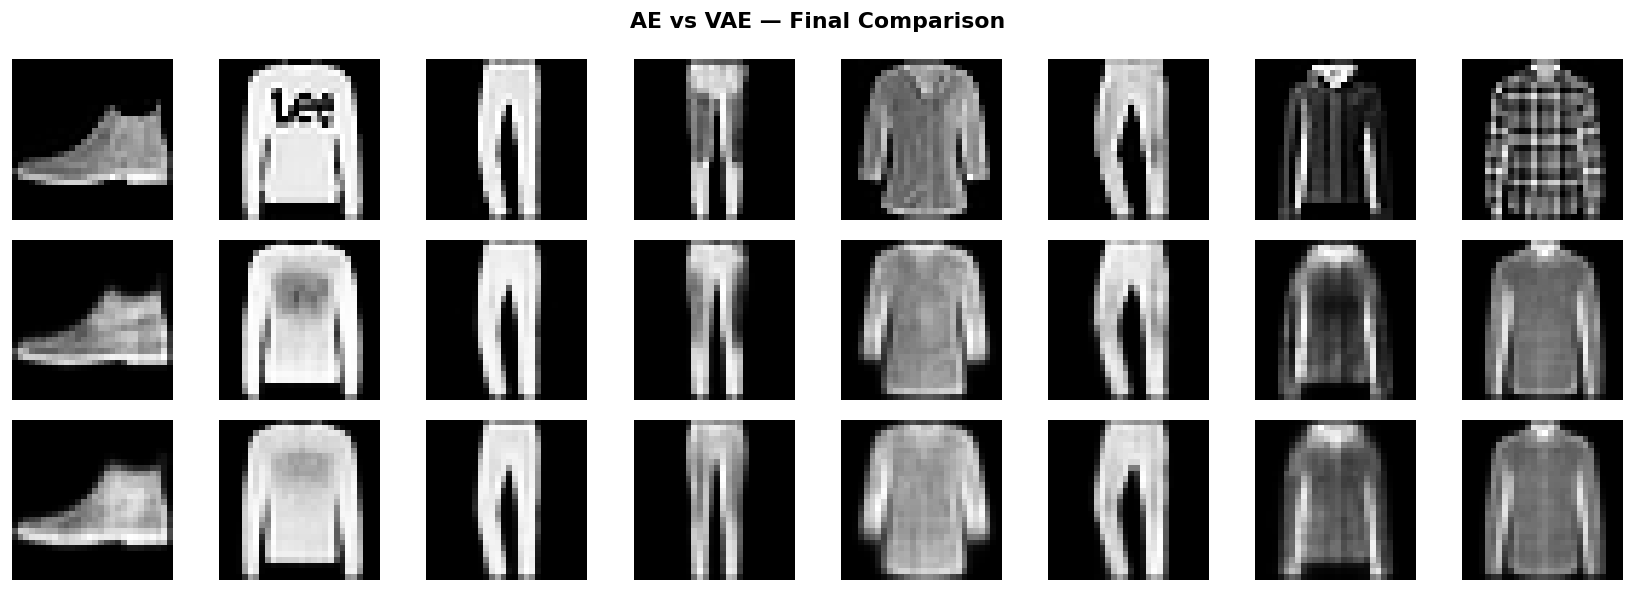


All runs logged to W&B. Check https://wandb.ai for your dashboard.


In [18]:
run = wandb.init(project='fashion-mnist-ae-vae', name='final_comparison', reinit=True)

imgs_fix = next(iter(test_loader))[0][:8].to(DEVICE)
with torch.no_grad():
    ae_r,  _      = ae_bce(imgs_fix)
    vae_r, _, _   = vae_main(imgs_fix)

fig, axes = plt.subplots(3, 8, figsize=(14, 5))
for j in range(8):
    axes[0,j].imshow(imgs_fix[j].cpu().squeeze(), cmap='gray'); axes[0,j].axis('off')
    axes[1,j].imshow(ae_r[j].cpu().squeeze(),     cmap='gray'); axes[1,j].axis('off')
    axes[2,j].imshow(vae_r[j].cpu().squeeze(),    cmap='gray'); axes[2,j].axis('off')
axes[0,0].set_ylabel('Original');      axes[1,0].set_ylabel('AE'); axes[2,0].set_ylabel('VAE')
plt.suptitle('AE vs VAE — Final Comparison', fontweight='bold')
plt.tight_layout(); plt.savefig('ae_vs_vae.png', bbox_inches='tight'); plt.show()

wandb.log({'ae_vs_vae_comparison': wandb.Image('ae_vs_vae.png')})
run.finish()
print('\nAll runs logged to W&B. Check https://wandb.ai for your dashboard.')


---
## 11. Analysis & Conclusion

### AE vs VAE
| | AE | VAE |
|---|---|---|
| Latent | Deterministic point | Distribution N(μ, σ²) |
| Reconstruction | Sharper | Slightly softer |
| Generation | ❌ Can't sample meaningfully | ✅ Sample z ~ N(0,I) |
| Interpolation | Artifacts at midpoints | Smooth, semantic |

### BCE vs MSE
BCE treats each pixel as Bernoulli — better suited for Fashion-MNIST's near-binary garment/background structure. MSE penalises large deviations uniformly and tends to produce blurrier reconstructions.

### Latent Dimension
Larger dims → lower reconstruction error, but diminishing returns above 16. Dim=2 gives a directly visualisable latent space but cannot encode enough detail. Dim=32 risks posterior collapse.

### KL Divergence
Acts as a regulariser that fills the latent space and enforces continuity. Without it (plain AE), the model encodes each image into an isolated point — no smooth path between classes exists.

### Optimizers
Adam converges fastest and most stably. SGD is slowest without careful LR/momentum tuning. RMSprop is a solid alternative to Adam for these architectures.

### Key Takeaway
Use an **AE** when you only need compression/reconstruction. Use a **VAE** when you need generation, interpolation, or a well-structured latent space.